# ⚙️ Fase 02: Arquitectura Base y Pipeline de Entrenamiento

**Objetivo del Notebook:**
Este cuaderno establece la infraestructura fundamental de *Machine Learning* para el proyecto. Su propósito es definir el *pipeline* de entrenamiento, configurar los hiperparámetros óptimos y ejecutar los primeros ciclos de aprendizaje profundo sobre el dataset sintético preprocesado.

**Flujo de ejecución (*Pipeline*):**
1. **Configuración del Entorno:** Inicialización del ecosistema de TensorFlow, gestión de la memoria gráfica y silenciado de advertencias operativas (*warnings*) para garantizar una ejecución limpia.
2. **Parametrización del Entrenamiento:** Definición de la función de pérdida (*Categorical Crossentropy*) para el problema multiclase y configuración del optimizador dinámico (*Adam*).
3. **Estrategias de Control (*Callbacks*):** Implementación de mecanismos de regularización técnica, incluyendo *Early Stopping* (para prevenir el *overfitting*) y *ReduceLROnPlateau* (para garantizar una convergencia suave hacia el mínimo de pérdida).
4. **Entrenamiento y Monitorización:** Ejecución iterativa de las épocas de aprendizaje y generación de las **curvas empíricas de evaluación** (*Loss* y *Accuracy*) para validar el comportamiento general de la red sobre datos no vistos.

In [1]:
import os
import warnings
import logging

# 1. Silenciar las advertencias estándar de Python
warnings.filterwarnings('ignore')

# Variables de entorno
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

# Importaciones
import tensorflow as tf
from tensorflow.keras import layers, models

# Silenciadores internos
tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(3)

import numpy as np
import matplotlib.pyplot as plt


In [ ]:


# ==========================================
# Definición de rutas relativas (Multiplataforma)
# ==========================================
# Como los notebooks están en la carpeta 'notebooks/', 
# usamos '..' para subir a la raíz del proyecto y luego entramos en 'data'
DATA_DIR = os.path.join("..", "data", "industrial_defect_dataset")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
META_CSV = os.path.join(DATA_DIR, "metadata.csv")
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Cargando conjunto de entrenamiento...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # Fundamental para usar Categorical Crossentropy
)

print("\nCargando conjunto de validación...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Extraemos el número real de clases (defectos) encontradas en las carpetas
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\nClases detectadas ({num_classes}): {class_names}")

# Habilitamos el Prefetching asíncrono para cargar los lotes directamente en la memoria RAM
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Cargando conjunto de entrenamiento...
Found 12000 files belonging to 5 classes.
Using 9600 files for training.

Cargando conjunto de validación...
Found 12000 files belonging to 5 classes.
Using 2400 files for validation.

Clases detectadas (5): ['crack', 'hole', 'normal', 'rust', 'scratch']


In [3]:

# Importaciones específicas para la arquitectura
from tensorflow.keras import layers, models
import tensorflow as tf

# 1. Definimos el bloque de Aumento de Datos Sintético
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2), # Rota la imagen aleatoriamente hasta un 20%
  layers.RandomZoom(0.2),     # Aplica un zoom aleatorio del 20%
], name="Capa_Data_Augmentation")

# 2. Construimos la Arquitectura del Modelo Base (Baseline)
model = models.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    
    # Integramos el Data Augmentation directamente al inicio
    data_augmentation,
    
    # Normalización de los píxeles (si no lo hiciste en la carga del dataset)
    layers.Rescaling(1./255),
    
    # Bloque Convolucional 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Bloque Convolucional 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Bloque Convolucional 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Aplanado y Capas Densas
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Previene el sobreajuste
    
    # Capa de salida: 5 neuronas (una por cada clase de defecto) con Softmax
    layers.Dense(5, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Data_Augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Definición de los Callbacks (Tus herramientas de control)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,               # Si no mejora en 5 épocas, corta el entrenamiento
    restore_best_weights=True # Recupera siempre la mejor versión
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,               # Reduce la tasa de aprendizaje a la mitad
    patience=3,               # Si se estanca 3 épocas
    min_lr=1e-6,              # Límite mínimo de reducción
    verbose=1                 # Te avisa por pantalla cuando lo hace
)

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Iniciando entrenamiento del modelo base...")

# Entrenamos guardando el registro en la variable "history"
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25, # Ponemos un límite alto; EarlyStopping lo parará cuando sea óptimo
    callbacks=[early_stopping, reduce_lr]
)

Iniciando entrenamiento del modelo base...
Epoch 1/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 108s 355ms/step - accuracy: 0.3883 - loss: 1.3749 - val_accuracy: 0.6737 - val_loss: 0.8300 - learning_rate: 0.0010
Epoch 2/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 110s 367ms/step - accuracy: 0.7510 - loss: 0.6760 - val_accuracy: 0.8925 - val_loss: 0.3408 - learning_rate: 0.0010
Epoch 3/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 111s 371ms/step - accuracy: 0.8604 - loss: 0.4200 - val_accuracy: 0.9446 - val_loss: 0.2189 - learning_rate: 0.0010
Epoch 4/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 111s 370ms/step - accuracy: 0.9438 - loss: 0.2002 - val_accuracy: 0.9629 - val_loss: 0.2318 - learning_rate: 0.0010
Epoch 5/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 110s 368ms/step - accuracy: 0.9391 - loss: 0.2055 - val_accuracy: 0.9750 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 6/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 112s 375ms/step - accuracy: 0.9560 - loss: 0.1506 - val_accuracy: 0.9804 - val_loss: 0.0808 - learning_rate: 0.0010
Epoch 7/25
300/300 ━━

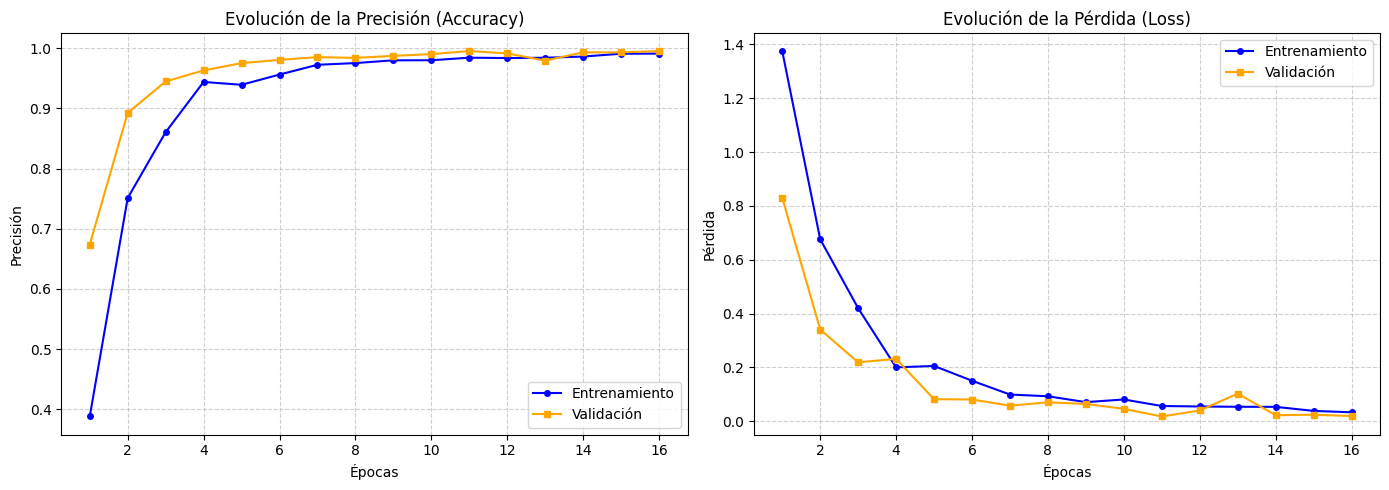

In [5]:
# Extraemos los datos del historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Creamos la figura con un tamaño profesional
plt.figure(figsize=(14, 5))

# Gráfica 1: Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, val_acc, label='Validación', color='orange', marker='s', markersize=4)
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

# Gráfica 2: Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, val_loss, label='Validación', color='orange', marker='s', markersize=4)
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()